In [1]:
import numpy as np
import os
from micado_misthic import misthic_func
from configobj import ConfigObj
from micado_misthic.utils.obsparams import * 
from astropy.table import Table
import matplotlib as mpl
import pandas as pd
import math

### Main directory of the repos
repository_dir              = 'C:/Users/Red Slottje/Documents/micado_misthic'

### directory with flux & transmission data for MICADO
flux_dir                    = repository_dir + '/flux_data/'

### directories with the coronagraphic simulated images
all_coro_sim_dir_prefix     = 'D:/FROM_RED/coro_sims/'

### directories to record the processed data
record_dir_prefix     = 'D:/FROM_RED/coro_adi_new/ADI/'

coronagraph     = 'CLC1' # 'CLC0' or 'CLC1'
quartile        = 'MED'#['Q1', 'Q4', 'MED']
keyword_NCPA    = 'NoNCPA' 
# lbd             = 1.582 # Choose filter
# p_dist_mas      = 13.052
duree = [60.0]
pixscale_in_mas = 1.5 # 1.5 or 4 mas
dist_pc = 10
r_pl    = 1
frame_exp_time = 10

airmass = 1.
telescope_pupil_file        = f'D:/FROM_NELLIE/INPUT_fromNellie/PUPIL/Pupil_ELT_v03.fits'

telescope_surface = get_aperture_surface(telescope_pupil_file)

spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'

save_constrast_dir = f'D:/FROM_RED/flux_and_contrasts/{quartile}_NoNCPA/{dist_pc}pc/'

# coro_sim_dir         = all_coro_sim_dir_prefix + f'{coronagraph}_{quartile}_NoNCPA/lambda={lbd:5.3f}/p_dist_mas={p_dist_mas}/TURBU_ABERR/duree={duree[0]}min/'
# #coro_resized_dir    =  record_dir_prefix + f'D:\FROM_RED\resized_fft_coro\CLC1_Q1_noNCPA\lbd={lbd}_pxscale={pixscale_in_mas}'
# coro_resized_dir = record_dir_prefix
# planet_resized_dir = record_dir_prefix+'PLANET/'

# ### path to the configspec file (same as the misthic_func.py module)
# configspec_file   = os.path.dirname(misthic_func.__file__)+'/misthic_configspec.ini'

# ### Read infos from the .ini file of the directory to process
# ini_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('.ini')][0]
# config  = ConfigObj(coro_sim_dir+ini_file, configspec=configspec_file)
# detector_sampling = np.float32(config['detectorconfig']['detector_sampling']) ## Sampling for initial simulation
# frame_exp_time  = np.float32(config['simuconfig']['delta_t']) ## exposure time per frame in seconds 

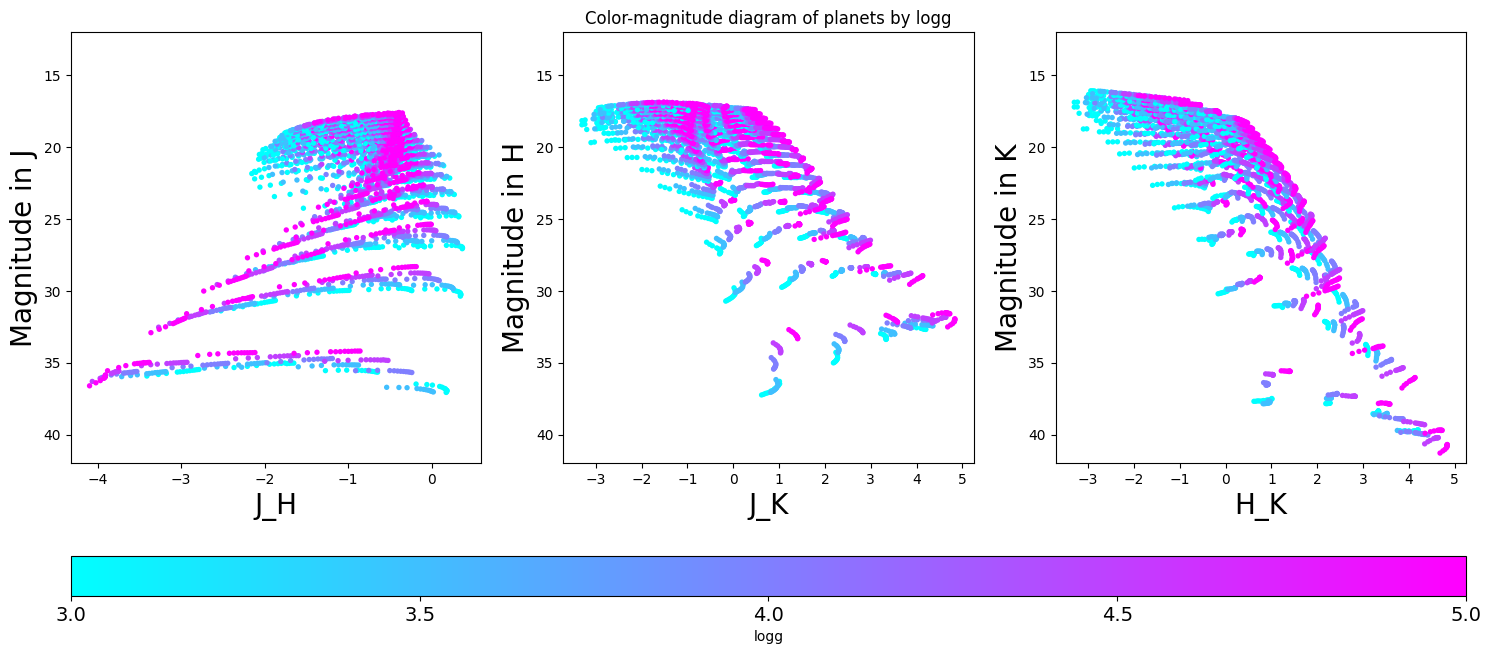

In [2]:
# Color - magnitude plots J, H, K
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig, ax = plt.subplots(1, 3, figsize=(18, 8), sharey=False)

metallicity = [0.32, 1.00, 3.16, 10.00]#, 31.62, 100.00]
#met = 0.32
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
#logg = 3.5
#CO = 0.45

CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(200, 1000, 50)



# metallicity = np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00])
# temp = np.arange(200, 1000, 50)
# logg = np.array([3.0, 3.5, 4.0, 4.5, 5.0])
# CO =  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
# lbd = np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])
# U_B, M_V, M_J, J_H, M_K, B_V =  pd.to_numeric(data[10:90,15], errors='coerce'), pd.to_numeric(data[10:90,7], errors='coerce'), pd.to_numeric(data[10:90,21], errors='coerce'), pd.to_numeric(data[10:90,19], errors='coerce'), pd.to_numeric(data[10:90:,22], errors='coerce'),  pd.to_numeric(data[10:90:,8], errors='coerce')
# logL, R_Rsun, masses, t_eff = pd.to_numeric(data[10:90,4], errors='coerce'), pd.to_numeric(data[10:90,6], errors='coerce'), pd.to_numeric(data[10:90,30], errors='coerce'), pd.to_numeric(data[10:90,1], errors='coerce')
# M_H = M_J - J_H
# M_U = M_V + B_V + U_B
# J_K = M_J - M_K
# H_K = M_H -M_K

color_code = logg
label = 'logg'

n = len(color_code)

if label == 'temp' :
    colors = plt.cm.plasma(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.plasma)
    cmap.set_array([])

if label == 'CO' :
    colors = plt.cm.viridis(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
    cmap.set_array([])
# idx = l

if label == 'logg' :
    colors = plt.cm.cool(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cool)
    cmap.set_array([])
# idx = j

if label == 'metallicity':
    colors = plt.cm.copper_r(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.LogNorm(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.copper_r)
    cmap.set_array([])

#need to index flux_zero to get the correct flux wavelengths
planet_mag_J = []
planet_mag_H = []
planet_mag_K = []
lbd_midband = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]
lbd_broadband =  [1.245 , 1.635, 2.145]


flux_zero   = fits.getdata(flux_dir+'Zero_mag_in_phot_per_m2_per_um_per_s.fits')

#print(flux_zero)
#planet_mag_broad_list = []
for i in range(len(temp)) :
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                #print ('indexes :', i, j, k, l)
                #print('temp = ', temp[i], 'logg = ', logg[j], 'met = ', metallicity[k], 'CO =', CO[l])
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0:
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, 
                                                flux_dir=flux_dir) # if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg}_met{metallicity}_CO{CO}.dat' != 0]

                else : 
                    continue
                
                planet_mag_J = []
                planet_mag_H = []
                planet_mag_K = []
                flux_ref =[]

                for n in range(len(lbd_broadband)):
                    if lbd_broadband[n] == 1.245 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.245]
                        #print('flux ref J =', flux_ref)
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time))
                        #print('flux ratio J =', flux_ratio)                      
                        planet_mag_J.append(-2.5*math.log(flux_ratio, 10))# if i != 0]
                        #planet_mag_J.append(-2.5*math.log(planet_photon_flux))

                    if lbd_broadband[n] == 1.635 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.635]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)  )              
                        #print('flux ref H =', flux_ref)
                        #print('flux ratio H =', flux_ratio)
                        planet_mag_H.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_H = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]

                    if lbd_broadband[n] == 2.145 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_K = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]
                        
                        #planet_mag_K.append(-2.5*math.log(planet_photon_flux))   

                J_H = -(np.array(planet_mag_J) - np.array(planet_mag_H))
                J_K = -(np.array(planet_mag_J) - np.array(planet_mag_K))
                H_K = -(np.array(planet_mag_H) - np.array(planet_mag_K))
                

                ax[0].scatter(J_H, planet_mag_J, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0].set_xlabel('J_H', fontsize = 20)
                ax[0].set_ylabel('Magnitude in J', fontsize = 20)
                ax[0].set_ylim(42, 12)
                ax[1].scatter(J_K, planet_mag_H, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1].set_xlabel('J_K', fontsize = 20)
                ax[1].set_ylabel('Magnitude in H', fontsize = 20)
                ax[1].set_ylim(42, 12)
                ax[2].scatter(J_K, planet_mag_K, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[2].set_xlabel('H_K', fontsize = 20)
                ax[2].set_ylabel('Magnitude in K', fontsize = 20)
                ax[2].set_ylim(42, 12)
ax[1].set_title(f'Color-magnitude diagram of planets by {label}')
cb = plt.colorbar(cmap, ax = ax, location = 'bottom', orientation = 'horizontal', aspect = 35, label = label, ticks = color_code)
cb.ax.tick_params(labelsize=14)

plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/mag_diag/Color coded by {label} UPDATED_{np.max(temp)}K_correct.png')
plt.show()

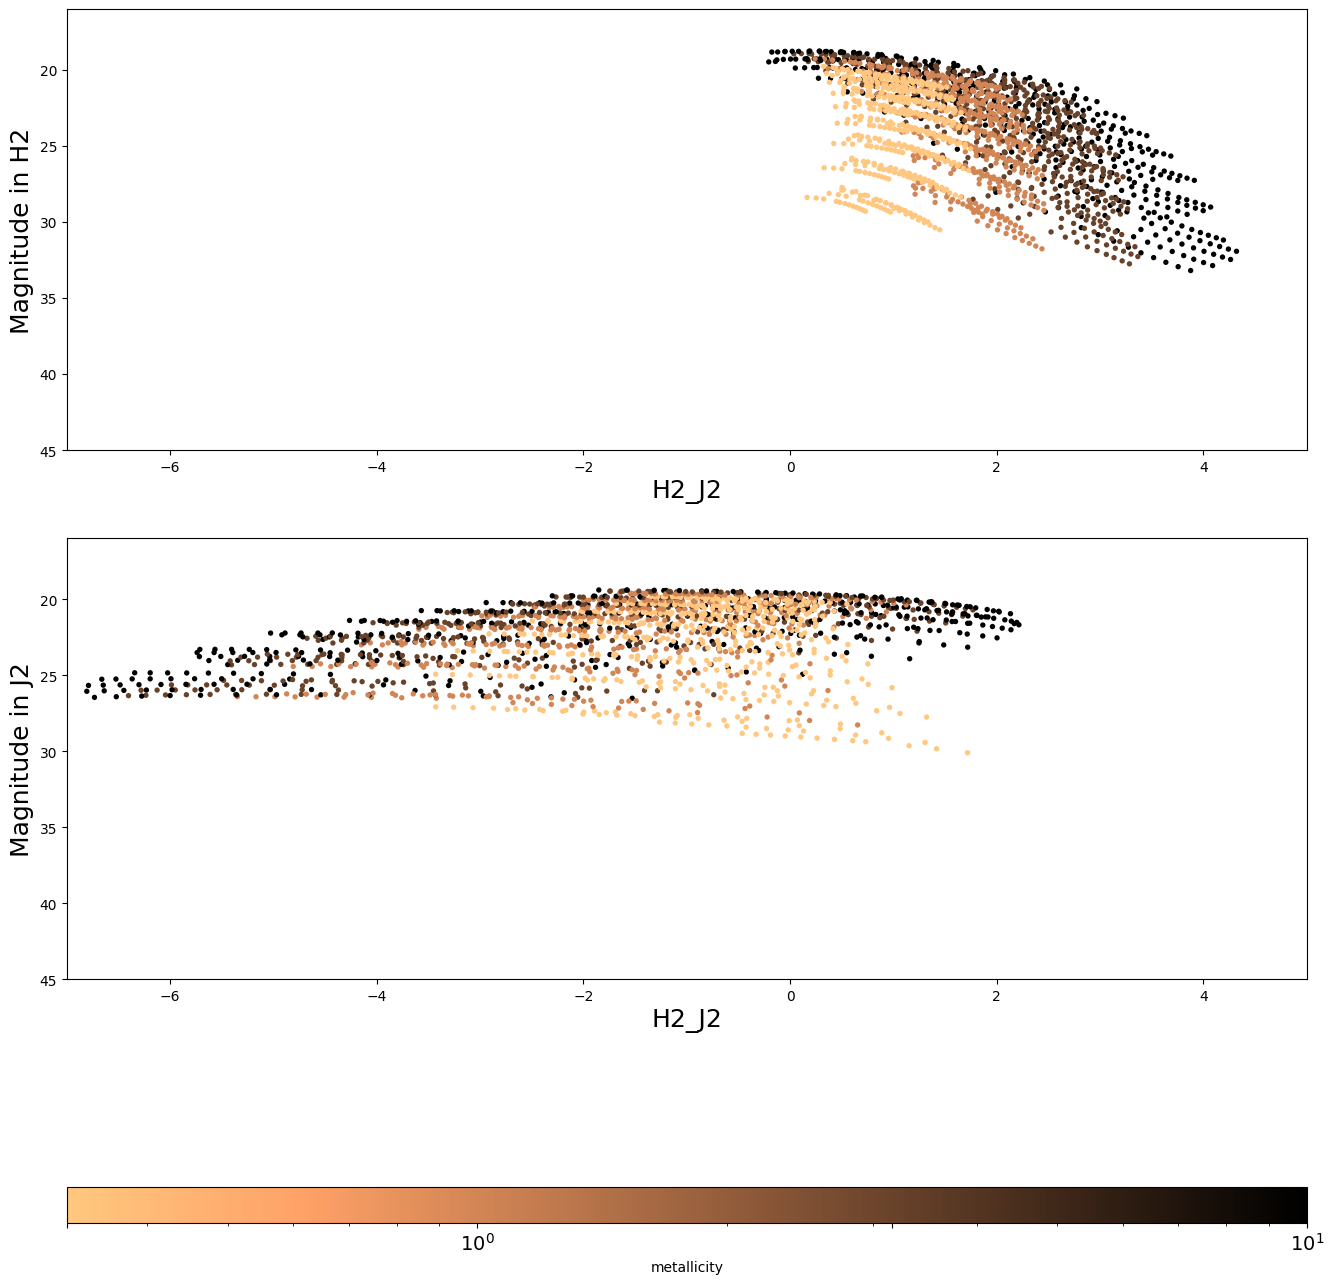

In [ ]:
# Color - magnitude plots J1- J2, H1-H2, K1-K2
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig, ax = plt.subplots(2, 1, figsize = (16,18), sharey=False)


spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'
metallicity = [0.32, 1.00, 3.16, 10.00]#, 31.62, 100.00]
#met = 0.32
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
#logg = 3.5
#CO = 0.45

CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(300, 700, 50)
r_pl    = 1
dist_pc = 10

color_code = CO
label = 'CO'

n = len(color_code)

if label == 'temp':
    colors = plt.cm.plasma(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.plasma)
    cmap.set_array([])

if label == 'CO' :
    colors = plt.cm.viridis(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
    cmap.set_array([])
    idx = l

if label == 'logg' :
    colors = plt.cm.cool(np.linspace(0,1,n))
    c = np.array(color_code)
    norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cool)
    cmap.set_array([])
# idx = j

if label == 'metallicity':
    c = np.array(color_code)
    colors = plt.cm.copper_r(np.linspace(0,1,n))
    norm = mpl.colors.LogNorm(vmin=c.min(), vmax=c.max())
    cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.copper_r)
    cmap.set_array([])
# idx = k

#need to index flux_zero to get the correct flux wavelengths
planet_mag_J = []
planet_mag_H = []
planet_mag_K = []
lbd_midband = [1.190, 1.270, 1.582, 1.693, 2.100, 2.235]
lbd_broadband =  [1.245 , 1.635, 2.145]


flux_zero   = fits.getdata(flux_dir+'Zero_mag_in_phot_per_m2_per_um_per_s.fits')

#print(flux_zero)
#planet_mag_broad_list = []
for i in range(len(temp)) :
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                #print ('indexes :', i, j, k, l)
                #print('temp = ', temp[i], 'logg = ', logg[j], 'met = ', metallicity[k], 'CO =', CO[l])
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0:
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, 
                                                flux_dir=flux_dir) # if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg}_met{metallicity}_CO{CO}.dat' != 0]

                else : 
                    continue
                
                planet_mag_J1 = []
                planet_mag_H1 = []
                planet_mag_K1 = []
                planet_mag_J2 = []
                planet_mag_H2 = []
                planet_mag_K2 = []
                flux_ref =[]

                for n in range(len(lbd_midband)):
                    if lbd_midband[n] == 1.190:
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.245]
                        #print('flux ref J =', flux_ref)
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time))
                        #print('flux ratio J =', flux_ratio)                      
                        planet_mag_J1.append(-2.5*math.log(flux_ratio, 10))# if i != 0]
                        #planet_mag_J.append(-2.5*math.log(planet_photon_flux))

                    if lbd_midband[n] == 1.270  :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.635]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time))                
                        #print('flux ref H =', flux_ref)
                        #print('flux ratio H =', flux_ratio)
                        planet_mag_J2.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_H = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]

                    if lbd_midband[n] ==1.582 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_H1.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] ==1.693 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_H2.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] == 2.100:
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K1.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] == 2.235 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/(flux_ref[0]*telescope_surface*frame_exp_time)) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K2.append(-2.5*math.log(flux_ratio, 10))

                J1_J2 = -(np.array(planet_mag_J1) - np.array(planet_mag_J2))
                H1_H2 = -(np.array(planet_mag_H1) - np.array(planet_mag_H2))
                K1_K2 = -(np.array(planet_mag_K1) - np.array(planet_mag_K2))
                K2_J2 = -(np.array(planet_mag_K2) - np.array(planet_mag_J2))
                H2_J2 = -(np.array(planet_mag_H2) - np.array(planet_mag_J2))
                K2_H2 = -(np.array(planet_mag_K2) - np.array(planet_mag_H2))
                
                ax[0].scatter(K1_K2, planet_mag_H2, color = colors[l], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0].set_xlabel('H2_J2', fontsize = 18)
                ax[0].set_ylabel('Magnitude in H2', fontsize = 18)
                ax[0].set_ylim(45, 16)
                ax[0].set_xlim(-7, 5)

                ax[1].scatter(H2_J2, planet_mag_J2, color = colors[l], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1].set_xlabel('H2_J2', fontsize = 18)
                ax[1].set_ylabel('Magnitude in J2', fontsize = 18)
                ax[1].set_ylim(45,16)
                ax[1].set_xlim(-7, 5)
                # ax[0][0].scatter(J1_J2, planet_mag_J1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[0][0].set_xlabel('J1-J2', fontsize = 18)
                # ax[0][0].set_ylabel('Magnitude in J1', fontsize = 18)
                # ax[0][0].set_ylim(21,9)
                # ax[1][0].scatter(H1_H2, planet_mag_H1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[1][0].set_xlabel('H1_H2', fontsize = 18)
                # ax[1][0].set_ylabel('Magnitude in H1', fontsize = 18)
                # ax[1][0].set_ylim(21,9)
                # ax[2][0].scatter(K1_K2, planet_mag_K1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[2][0].set_xlabel('K1_K2', fontsize = 18)
                # ax[2][0].set_ylabel('Magnitude in K1', fontsize = 18)
                # ax[2][0].set_ylim(21,9)
                
                # ax[0][1].scatter(J1_J2, planet_mag_J2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[0][1].set_xlabel('J1-J2', fontsize = 18)
                # ax[0][1].set_ylabel('Magnitude in J2', fontsize = 18)
                # ax[0][1].set_ylim(21,9)
                # ax[1][1].scatter(H1_H2, planet_mag_H2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[1][1].set_xlabel('H1_H2', fontsize = 18)
                # ax[1][1].set_ylabel('Magnitude in H2', fontsize = 18)
                # ax[1][1].set_ylim(21,9)
                # ax[2][1].scatter(K1_K2, planet_mag_K2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[2][1].set_xlabel('K1_K2', fontsize = 18)
                # ax[2][1].set_ylabel('Magnitude in K2', fontsize = 18)
                # ax[2][1].set_ylim(21,9)
#plt.title('Color-magnitude diagram of planets by CO')
cb = plt.colorbar(cmap, ax = ax, location = 'bottom', orientation = 'horizontal', aspect = 35, label = label, ticks = color_code)
cb.ax.tick_params(labelsize=14)
plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/mag_diag/Mag K2_J2 color coded by {label}_{np.max(temp)}K_corrected.png')
plt.show()

In [4]:
# with open('D:/FROM_RED/COND03_models_a_utiliser.txt') as data :#, dtype='str')
#     for x in data :
#         print(x)
data = pd.read_csv('D:/FROM_RED/COND03_models_a_utiliser.txt', sep="\t", header = 10)
data = data.copy()
#print(data[:,3])

#M_V, M_J, M_H, M_K =  pd.to_numeric(data[19:43,5], errors='coerce'), pd.to_numeric(data[19:43,9], errors='coerce'), pd.to_numeric(data[19:43,10], errors='coerce'), pd.to_numeric(data[19:43,11], errors='coerce')
#logL, R_Rsun, masses, t_eff = pd.to_numeric(data[19:43,2], errors='coerce'), pd.to_numeric(data[19:43,4], errors='coerce'), pd.to_numeric(data[19:43,0], errors='coerce'), pd.to_numeric(data[19:43,1], errors='coerce')


# c = np.array(metallicity)
# norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
# cmap.set_array([])

# n = len(metallicity)
# colors = plt.cm.viridis(np.linspace(0,1,n))
# for j in range(len(CO)):
#     fig, ax = plt.subplots(dpi=100)
#     for k in range(len(metallicity)):
#         planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[k], CO[j], dist_pc, r_pl, flux_dir=flux_dir)
#         plt.plot(spec_wave,planet_flux, color = colors[k])

#     plt.colorbar(cmap, ax = ax)
#     plt.title(f'Photon flux depending on metallicity (CO = {CO[j]})')
#     plt.xlabel('Wavelength (µm)')
#     plt.ylabel('Flux (photons/s/m²)')
#     plt.show()

#plt.scatter(t_eff, M_H)
                # ax[0].scatter(H1_H2, planet_mag_H1, color = colors[i], s=15, edgecolor='none', label='planet_mag', zorder=1)
                # ax[0].set_xlabel('H1_H2', fontsize = 18)
                # ax[0].set_ylabel('Magnitude in H1', fontsize = 18)
                # ax[0].set_ylim(21,2)